In [1]:
from typing import Annotated
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from langchain.agents.middleware import FilesystemFileSearchMiddleware
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from deepagents.backends import FilesystemBackend
from deepagents.middleware.filesystem import FilesystemMiddleware

load_dotenv()

DATA_DIR = "../examples-data"

model = ChatOpenAI(
    model="deepseek-v4-flash",
    extra_body={"thinking": {"type": "disabled"}},
    temperature=0.2,
)

D:\Documents\GitHub\learn-langchain\.venv\Lib\site-packages\langchain_core\utils\pydantic.py:42: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1 import BaseModel as BaseModelV1


In [6]:
backend = FilesystemBackend(
    root_dir=DATA_DIR,
    virtual_mode=True,
)

SEARCH_MIDDLEWARE = FilesystemFileSearchMiddleware(
    root_path=str(DATA_DIR),
    use_ripgrep=True,
)

EDITOR_SYSTEM_PROMPT = """
你是 Markdown 文档目录结构整理专家，你的工作是使 Markdown 标题结构合理。修改文件只能使用 edit_file。

## 工作流程

- 使用 grep_search 检索文件中是否存在「目录」，检索时允许“目”和“录”之间存在空格；如果存在，读取该位置及其后少量内容以获取 TOC；如果不存在，则跳过 TOC。
- 使用 grep_search 提取正文中全部 Markdown 标题及行号，pattern 固定为 `^#{1,6} `。
- 比较 TOC 与正文标题结构；如果不存在 TOC，则按章节编号和上下级关系分析标题结构，一次性确认全部问题。
- 使用 edit_file 修正标题层级，只修改标题相关内容。
- 修改完成后再次使用 grep_search 提取标题并复核。

## 修改规则

- **按编号确定层级**：有明确章节编号时，按编号深度确定 Markdown 层级，如 `1`、`第一章` 使用 `#`，`1.1` 使用 `##`，`1.1.1` 使用 `###`。
- **参考 TOC 层级**：文档前部存在自带 TOC 时，优先参考 TOC 的章节关系和编号形式校对正文标题层级，不要盲从当前的 `#` 数量。
- **降级封面标题**：正文开头的文档封面大标题（如 `# XX方案`）不是章节，降级为 `**加粗**`。
- **降级"目录"二字所在行**：正文中字面为「目录」的一行（如 `## 目录`）不是章节标题，降级为 `**加粗**`。
- **补充缺失标题**：TOC 中有但正文未被解析为标题的章节（如仅加粗或遗漏 `#`），按 TOC 层级手动补充为 `#` 正文标题。
- **降级非 TOC 小标题**：正文内更细碎的编号（如"一、""1、""（1）""1.1.1.1.1"等），若未在 TOC 中出现，一律不用 `#` 标题，改为 `**加粗**`。
- **清理标题格式**：`#` 与标题文字之间保留一个半角空格。

## 读取约束

- 仅当定位 TOC、确认具体待修改标题或执行明确修改确有必要时，才允许读取相关位置的最小范围内容。禁止通读正文、扩大读取范围、重复读取相同区域或进行大范围读取。

## Auditor 反馈处理

- 如果收到 Auditor 反馈，只处理其指出的问题，不重新扫描整个文档。
"""

editor_agent = create_agent(
    model,
    system_prompt=EDITOR_SYSTEM_PROMPT,
    middleware=[
        FilesystemMiddleware(backend=backend, tools=["ls", "read_file", "edit_file"]),
        SEARCH_MIDDLEWARE,
    ],
)

AUDITOR_SYSTEM_PROMPT = """
你是 Markdown 文档结构审计员。你的工作是确认 Markdown 标题结构合理。只检查，不修改文件。

## 工作流程

- 从当前 message 中确定目标 Markdown 文件。
- 使用 grep_search 提取全部 Markdown 标题及行号，pattern 固定为 `^#{1,6} `。
- 根据标题、编号、层级和顺序检查结构，一次性确认全部问题。
- 输出审计结论后立即结束。

## 检查规则

- **检查标题层级**：标题层级是否合理、连续，不存在无依据的跨级。
- **检查编号层级**：章节编号与 Markdown 层级是否匹配，如 `1`、`第一章` 对应 `#`，`1.1` 对应 `##`，`1.1.1` 对应 `###`。
- **检查非章节标题**：细碎编号或非章节小标题是否误用了 `#`。
- **检查封面标题**：正文开头的文档封面大标题是否误用了 `#`。
- **检查目录行**：字面为「目录」或「目 录」的行是否误用了 `#`。
- **检查标题格式**：`#` 与标题文字之间是否只保留一个半角空格。

## 读取约束

- 仅当确认具体审计问题确有必要时，才允许读取相关位置的最小范围内容。禁止通读正文、扩大读取范围、重复读取相同区域或进行大范围读取。

## 输出

- **通过**：简要说明审计结果，并以 `[AUDIT_PASS]` 结尾。
- **不通过**：只列出确认存在的问题，包括行号、问题和建议修改方式，并以 `[AUDIT_FAIL]` 结尾。
"""

auditor_agent = create_agent(
    model,
    system_prompt=AUDITOR_SYSTEM_PROMPT,
    middleware=[
        SEARCH_MIDDLEWARE,
    ],
)


class AgentState(BaseModel):
    """工作流状态：messages 承载 Editor 对话；不接入 checkpointer，单次运行即起即止。"""

    messages: Annotated[list[BaseMessage], add_messages] = Field(default_factory=list)
    is_valid: bool = False
    attempts: int = 0
    audit_feedback: str = ""


def auditor_node(state: AgentState) -> dict:
    """审计并评估：计数、审计、打回逻辑全部收敛在本节点内。"""
    attempts = state.attempts + 1

    original_request = state.messages[0].content
    audit_message = HumanMessage(
        content=(
            "请执行一次独立的 Markdown 结构审计。\n\n"
            f"原始任务（用于确定目标文件）：{original_request}\n\n"
            f"Editor 已完成第 {attempts} 次修改，请直接检查上述目标文件。"
        )
    )
    result = auditor_agent.invoke({"messages": [audit_message]})
    feedback = result["messages"][-1].content.strip()

    if "[AUDIT_PASS]" in feedback:
        return {"attempts": attempts, "is_valid": True, "audit_feedback": feedback}

    retry_message = HumanMessage(
        name="Auditor",
        content=(
            f"第 {attempts} 次修改未通过审计。\n\n"
            f"审计反馈：\n{feedback}\n\n"
            "请严格按照上面的具体行号和问题，使用工具修复目标 Markdown 文件。"
        ),
    )
    return {
        "attempts": attempts,
        "is_valid": False,
        "audit_feedback": feedback,
        "messages": [retry_message],
    }


def should_continue(state: AgentState) -> str:
    if state.is_valid:
        return END

    if state.attempts >= 3:
        return "fail"

    return "editor"


def fail_node(state: AgentState) -> dict:
    raise RuntimeError(
        f"经过 {state.attempts} 次修改仍未通过审计，流程终止。\n"
        f"最后一次反馈：\n{state.audit_feedback}"
    )


builder = StateGraph(AgentState)

builder.add_node("editor", editor_agent)
builder.add_node("auditor", auditor_node)
builder.add_node("fail", fail_node)

builder.add_edge(START, "editor")
builder.add_edge("editor", "auditor")

builder.add_conditional_edges(
    "auditor",
    should_continue,
    {
        "editor": "editor",
        "fail": "fail",
        END: END,
    },
)

graph = builder.compile()

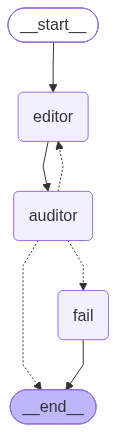

In [7]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [8]:
md_file = "test.md"
try:
    for chunk in graph.stream(
            {"messages": [HumanMessage(content=f"请检查并修正 Markdown 文件 `{md_file}` 的标题层级结构。")]},
            stream_mode="values",
            version="v2",
            subgraphs=True
    ):
        ns = chunk.get("ns") or ()
        print(ns[0].split(":")[0] if ns else "root")
        message = chunk["data"].messages[-1]  # data 是 AgentState(pydantic)，不是 dict
        message.pretty_print()

except RuntimeError as e:
    print(f"\n💥 流程终止：{e}")

print("\n🎉 审计通过，流程结束。")

root
================================ Human Message =================================

请检查并修正 Markdown 文件 `test.md` 的标题层级结构。
editor
================================ Human Message =================================

请检查并修正 Markdown 文件 `test.md` 的标题层级结构。
editor
================================== Ai Message ==================================
Tool Calls:
  ls (call_00_yxAwX9AmD1l5hloqDl3n0852)
 Call ID: call_00_yxAwX9AmD1l5hloqDl3n0852
  Args:
    path: .
  grep_search (call_01_HHngZihbdcgflR1OpPDl4610)
 Call ID: call_01_HHngZihbdcgflR1OpPDl4610
  Args:
    pattern: 目\s*录
    path: .
    include: test.md
    output_mode: content
  grep_search (call_02_BhjJc7b8XN4O7LyaV5hU6925)
 Call ID: call_02_BhjJc7b8XN4O7LyaV5hU6925
  Args:
    pattern: ^#{1,6} 
    path: .
    include: test.md
    output_mode: content
editor
================================= Tool Message =================================
Name: grep_search

/test.md:1:# 广西管道公司管道主干线地质灾害专业排查及风险评估项目地质灾害专业排查及风险评估报告
/test.md:5:# 广西管道公司管道主干线地质